# The Finite Triangular Quantum Well


---

### Abstract

We have the stationary Schrödinger problem for a particle of effective mass $m$
in the piecewise potential

$$
U(x) \;=\; \begin{cases}
\;0, & x < 0 \\[3pt]
\;\dfrac{U_0}{a}\, x, & 0 \le x \le a \\[6pt]
\;U_0, & x > a
\end{cases}
$$

This potential is the minimal model for the band-bending profile near a
GaAs/AlGaAs heterojunction, the inversion layer in a MOSFET, and the
tip–sample region in an STM under bias. In the linear ramp the
Schrödinger equation reduces *exactly* to **Airy's equation**, so the
two natural solutions there are $\mathrm{Ai}(\xi)$ and $\mathrm{Bi}(\xi)$.

Physical observables computed below:
* the bound (quasi-bound) energy levels $E_n$,
* the normalised stationary wavefunctions $\psi_n(x)$,
* the probability densities $|\psi_n(x)|^2$,
* the scattering states above $U_0$ and their qualitative behaviour.



## Notebook plan and how to read this document

The notebook is divided into **four stages** so that it can be read either
as a tutorial or as a finished computational-physics lab report.

| Stage | Content |
|-------|---------|
| **1 (this section)** | Physical motivation; statement of the problem; Schrödinger equation in three regions; emergence of Airy functions; matching/continuity conditions; bound vs scattering states; dimensionless variables. |
| **2** | Numerical method: finite-difference discretisation, construction and diagonalisation of the Hamiltonian, implementation of $U(x)$, choice of computational domain. |
| **3** | Eigenvalue search; wavefunction normalisation; publication-quality plots of $U(x)$, $\psi_n(x)$, $\lvert\psi_n(x)\rvert^2$, and the energy ladder; interpretation. |
| **4** | Interactive `ipywidgets` sliders for $U_0,\ a,\ m$, number of grid points $N$; toggle bound$\leftrightarrow$scattering states; parameter studies; convergence/accuracy discussion; final remarks. |




## 1. Physical motivation

Triangular potential wells appear in a striking variety of nanostructure
contexts:

* **Two-dimensional electron gases (2DEGs)** at GaAs/AlGaAs heterojunctions
  and the Si/SiO$_2$ inversion layer of a MOSFET.
* **Quantum-cascade lasers** and **resonant-tunneling diodes**.
* **Scanning tunneling microscopy (STM)**. Under bias, the vacuum gap
  between tip and sample is a finite triangular barrier.
* **Quantum bouncing neutrons.** Ultracold neutrons in the gravitational
  field above a horizontal mirror experience a linear potential bounded by
  a hard wall.


> **Notation.** Throughout, $m$ is the (effective) mass of the particle
> — for an electron in a semiconductor, the effective mass $m^* \ll m_e$.

> $\hbar$ is the reduced Planck constant and $E$ is the energy of a
> stationary state.

---


## 2. The triangular quantum well — hard-wall convention

We work with these conditions: an infinite barrier
at $x=0$, a linear ramp on $[0,a]$, and a finite barrier of height $U_0$
for $x>a$:

$$
U(x) \;=\; \begin{cases}
\;\infty, & x<0 \quad\text{(region 0 — hard wall)}\\[4pt]
\;\dfrac{U_0}{a}\,x, & 0\le x\le a \quad\text{(region I — linear ramp)}\\[6pt]
\;U_0, & x>a \quad\text{(region II — flat barrier)}.
\end{cases}
$$

**Key consequence.** The hard wall confines the particle to $x>0$ and
ensures that states with $E<U_0$ are **truly bound**: the spectrum on
$E<U_0$ is discrete, and the eigenfunctions are square-integrable.
For $E>U_0$ the spectrum is continuous.


Qualitative observations:

* $U(x)$ is finite and continuous for $x\ge 0$. The point $x=a$ is a
  kink in $U'$, not a jump.
* The classical turning point at energy $E$ (with $0<E<U_0$) lies inside
  region I at
  $$x_E \;=\; \frac{E\,a}{U_0}.$$
  For $0<x<x_E$ the particle is classically allowed, for $x_E<x<a$ and
  $x>a$ it is classically forbidden.
* The wavefunction must satisfy
  $\psi(0)=0$  (hard wall) and $\psi(x)\to 0$ as $x\to\infty$
  (square-integrability). Both are essential — the first turns the
  ramp into a "well", the second selects discrete energies.

A pictorial sketch:

```
U(x)
  ^
  | ||
  | ||
U0|  ||---------------- ......
  | ||             . /
  | ||           . /
  | ||         . /
  | ||       . /
  | ||     ./
  | ||   ./
  | || ./
 0| ||/____________________________
  || 0          a                  x
   wall  (region I)   (region II)
```

---


## 3. The stationary Schrödinger equation

We seek stationary states $\psi(x)$ of energy $E$ satisfying

$$
\boxed{\;-\frac{\hbar^{2}}{2m}\,\frac{d^{2}\psi}{dx^{2}}
       \;+\; U(x)\,\psi(x) \;=\; E\,\psi(x)\;}
\qquad (\star)
$$

In each region of constant or linear $U(x)$ the ODE is solved in closed
form; the three pieces are glued together by **boundary conditions**.

### 3.1 Region 0 ($x<0$): hard wall

$U=\infty$ here, so the particle is excluded:

$$\psi(x) \;=\; 0\qquad (x<0).$$

The hard wall enforces the **Dirichlet condition**

$$\boxed{\;\psi(0) \;=\; 0.\;}$$

Unlike at a finite step, the derivative $\psi'$ **need not be
continuous** at a hard wall — only $\psi$ itself must vanish there.
This is because integrating $(\star)$ across $x=0$ with
$U=\infty$ on one side does not give a finite jump condition for
$\psi'$.
### 3.2 Region I ($0\le x\le a$): linear ramp
Here $U(x)=(U_0/a)\,x$ and $(\star)$ becomes

$$
\frac{d^{2}\psi}{dx^{2}}
\;=\;\frac{2m}{\hbar^{2}}\!\left[\frac{U_{0}}{a}\,x-E\right]\psi.
$$

The coefficient of $\psi$ is *linear in $x$* — the fingerprint of
Airy's equation. Bringing it to canonical form by shifting to the
classical turning point and rescaling,

$$
\xi \;=\; \alpha\,(x-x_E), \qquad x_E=\frac{E\,a}{U_0},\qquad
\alpha \;=\; \left(\frac{2m\,U_0}{\hbar^{2}\,a}\right)^{\!1/3}.
$$

Note that $\alpha$ has units of inverse length, $\xi$ is dimensionless,
$\xi>0$ corresponds to the classically forbidden subregion and $\xi<0$
to the classically allowed subregion.

The chain rule $d/dx=\alpha\,d/d\xi$ gives

$$
\alpha^{2}\frac{d^{2}\psi}{d\xi^{2}}
\;=\;\frac{2m}{\hbar^{2}}\,\frac{U_{0}}{a}\,\frac{\xi}{\alpha}\,\psi
\;=\;\alpha^{2}\,\xi\,\psi,
$$

where the last step uses $\alpha^{3}=2mU_0/(\hbar^{2}a)$. Cancelling
$\alpha^{2}$ leaves **Airy's equation**:

$$
\boxed{\;\frac{d^{2}\psi}{d\xi^{2}} \;=\; \xi\,\psi(\xi)\;}
$$

The two linearly independent solutions are the **Airy functions**
$\mathrm{Ai}(\xi)$ and $\mathrm{Bi}(\xi)$, so

$$
\psi_{\mathrm I}(x) \;=\;
C\,\mathrm{Ai}\bigl(\alpha(x-x_E)\bigr)\;+\;
D\,\mathrm{Bi}\bigl(\alpha(x-x_E)\bigr).
$$

### Key notes about Airy functions

Airy's equation $y''(\xi)=\xi\,y(\xi)$ is the canonical second-order ODE
with a coefficient linear in the independent variable.

Key qualitative facts:

* $\mathrm{Ai}(\xi)$ **decays super-exponentially** as $\xi\to+\infty$
  (classically forbidden side):
  $\mathrm{Ai}(\xi)\sim\dfrac{1}{2\sqrt{\pi}}\,\xi^{-1/4}
   \exp\!\bigl(-\tfrac{2}{3}\xi^{3/2}\bigr)$.
* $\mathrm{Ai}(\xi)$ **oscillates** as $\xi\to-\infty$
  (classically allowed side):
  $\mathrm{Ai}(\xi)\sim\dfrac{1}{\sqrt{\pi}}\,|\xi|^{-1/4}
   \sin\!\bigl(\tfrac{2}{3}|\xi|^{3/2}+\tfrac{\pi}{4}\bigr)$.
* $\mathrm{Bi}(\xi)$ **grows** super-exponentially as $\xi\to+\infty$
  and oscillates as $\xi\to-\infty$.
* Both are smooth and finite at $\xi=0$ (the turning point itself is
  *not* a singularity of the wavefunction).

The zeros of $\mathrm{Ai}$, denoted $a_n$ ($n=1,2,\dots$), are all
**negative** and accumulate towards $-\infty$:
$$a_1\approx-2.3381,\; a_2\approx-4.0879,\; a_3\approx-5.5206,\;\dots$$


In a **semi-infinite linear potential** (linear $U$ all the way to
$+\infty$, plus a hard wall) the boundary condition $\psi\to 0$ at
infinity kills $\mathrm{Bi}$, leaving only $\mathrm{Ai}$, and the
hard-wall condition $\mathrm{Ai}(-\alpha x_E)=0$ quantises the energy
through the Airy zeros: $E_n=|a_n|\,U_0/(\alpha a)$.

In our **finite triangular well**, region I has both endpoints at
*finite* positions, so **both** $\mathrm{Ai}$ and $\mathrm{Bi}$ are
allowed in the ramp.

### 3.3 Region II ($x>a$): flat barrier

Here $(\star)$ becomes
$\psi''=(2m/\hbar^{2})(U_0-E)\,\psi.$
Two cases:

* **Bound regime ($E<U_0$).**
  Set $\kappa=\sqrt{2m(U_0-E)}/\hbar$. The decaying solution
  $$\psi_{\mathrm{II}}(x) \;=\; F\,e^{-\kappa(x-a)}$$
  is selected by the requirement that $\psi$ be square-integrable
  ($\psi\to 0$ as $x\to\infty$). The wavefunction decays exponentially
  into the barrier with characteristic length $1/\kappa$ — the
  evanescent tail visible in textbook plots.

* **Scattering regime ($E>U_0$).**
  Set $k_3=\sqrt{2m(E-U_0)}/\hbar$. The solution
  $\psi_{\mathrm{II}}(x)=F\,e^{+ik_3 x}+G\,e^{-ik_3 x}$ is oscillatory;
  these states are not square-integrable and form a continuum.

---


## 4. Boundary and continuity conditions (matching procedure)

The three regions are glued together by the requirement that $\psi(x)$
be a single smooth function in regions where $U$ is finite, plus the
hard-wall condition where it is infinite.

**At the hard wall** ($x=0$): only $\psi$ itself must vanish,
$$
\psi(0)\;=\;0.
$$
The derivative $\psi'$ is unconstrained there: it generally jumps as
the wavefunction reflects off the wall.

**At the finite step** ($x=a$): since $U$ is finite on both sides
(jump from $U_0\,a/a = U_0$ to $U_0$ — actually no jump, the potential
is continuous at $x=a$ but $U'$ has a kink), *both* $\psi$ and $\psi'$
must be continuous:
$$
\psi_{\mathrm I}(a) = \psi_{\mathrm{II}}(a), \qquad
\psi_{\mathrm I}'(a) = \psi_{\mathrm{II}}'(a).
$$

> Integrating $(\star)$
> across $[a-\varepsilon,a+\varepsilon]$,
>
>$\displaystyle -\frac{\hbar^{2}}{2m}\bigl[\psi'(a^{+})-\psi'(a^{-})\bigr]
=\int_{a-\varepsilon}^{a+\varepsilon}(E-U)\psi\,dx \xrightarrow[\varepsilon\to 0]{} 0,$
> so $\psi'$ has no jump because $U$ is finite. Continuity of $\psi$
> follows from $\psi'$ existing in the integrated sense.

### Counting equations and unknowns (bound case $E<U_0$)

* Region 0: no coefficient (wavefunction identically zero).
* Region I:  two coefficients $C, D$ (the $\mathrm{Ai},\mathrm{Bi}$
  amplitudes).
* Region II: one coefficient $F$ (the decaying exponential; the
  growing one is killed by $\psi\to0$ at infinity).

Total unknowns: $3$ ($C,D,F$). Total equations:
$\psi(0)=0$, plus two matching conditions at $x=a$ → $3$ linear
homogeneous equations. Non-trivial solutions exist only when the
determinant of the $3\times 3$ coefficient matrix vanishes:

$$
\det\mathcal{M}(E)\;=\;0.
$$


---


## 5. Bound states vs. scattering states

With the hard wall in place, the spectrum has a clean two-part
structure:

### 5.1 Discrete bound spectrum, $E<U_0$

These are genuine **bound states**: square-integrable, with discrete
energies $E_1<E_2<\cdots<U_0$. The wavefunction
* vanishes at $x=0$ (hard wall),
* is a linear combination of $\mathrm{Ai}/\mathrm{Bi}$ on $[0,a]$,
* decays exponentially for $x>a$ with rate
  $\kappa=\sqrt{2m(U_0-E)}/\hbar$.


### 5.2 Continuous scattering spectrum, $E>U_0$

Above the barrier the wavefunction oscillates on $[a,\infty)$ and is
not normalisable. Physical states form a *continuum*.

Numerically we put the problem in a finite box $[0,\tilde L]$ with a
second hard wall at $x=\tilde L$, far enough from the ramp that the
low-lying bound levels are insensitive to $\tilde L$. The price is
that the *scattering* part of the spectrum is **discretised by the
right wall** into "box modes" — useful for visualising representative
above-barrier wavefunctions, but not literal eigenenergies of the
infinite problem. We will be explicit about this in Stages 3–4.



---


## 6. Dimensionless variables


Two natural scales are present: the length $a$ and the energy $U_{0}$.
Define

$$
\tilde x \;=\; \frac{x}{a}, \qquad
\tilde E \;=\; \frac{E}{U_{0}}, \qquad
\tilde U(\tilde x) \;=\; \frac{U(x)}{U_{0}}.
$$

The dimensionless potential is

$$
\tilde U(\tilde x) \;=\; \begin{cases}
0, & \tilde x < 0 \\[2pt]
\tilde x, & 0\le\tilde x\le 1 \\[2pt]
1, & \tilde x > 1.
\end{cases}
$$

Substituting into $(\star)$, dividing by $U_{0}$, and using
$d^{2}/dx^{2}=a^{-2}\,d^{2}/d\tilde x^{2}$ gives

$$
-\,\frac{1}{2\beta^{2}}\,\frac{d^{2}\psi}{d\tilde x^{2}}
\;+\;\tilde U(\tilde x)\,\psi
\;=\;\tilde E\,\psi,
$$

where the only remaining parameter is the dimensionless
**well-strength**

$$
\boxed{\;\beta^{2}\;=\;\frac{m\,U_{0}\,a^{2}}{\hbar^{2}}.\;}
$$

Physically:

* $\beta\gg 1$ → "deep" or "wide" well — supports many bound states.
* $\beta\lesssim 1$ → shallow / narrow well — supports one or no bound
  states.

This single parameter $\beta$ controls the entire spectrum
$\{\tilde E_{n}(\beta)\}$.

In terms of $\beta$ the Airy length-scale becomes
$\alpha a = (2\beta^{2})^{1/3}$, so the dimensionless Airy variable in
region II is

$$
\xi \;=\; (2\beta^{2})^{1/3}\,(\tilde x - \tilde E).
$$


---


---
# Stage 2 — Numerical method

In Stage 1 we obtained the analytical structure of the problem in each
region. We now turn to the **numerical solution**, which will give us
the bound-state energies and wavefunctions for arbitrary parameters
without solving a transcendental equation by hand.

### Plan for this stage

1. Imports and physical constants.
2. Default physical parameters $(U_0, a, m)$ and computation of $\beta^{2}$.
3. Implementation of the dimensionless potential $\tilde U(\tilde x)$,
   written modularly so it can be swapped.
4. Sanity-check plot of the potential.
5. Derivation and construction of the tri-diagonal finite-difference
   Hamiltonian.
6. The solver function and a first "smoke-test" run.

---


## 2.1 Imports

We will use:
* `numpy` for array operations,
* `scipy.linalg.eigh_tridiagonal` for **fast symmetric tridiagonal
  diagonalisation** (this is the workhorse — much faster than dense
  `eigh` for $N\gtrsim 10^{3}$),
* `scipy.special.airy` for the analytical Airy-function cross-check
  in Stage 3,
* `scipy.optimize.brentq` for root-finding (also used in the
  Stage 3 cross-check and in Stage 4 transmission curves),
* `matplotlib` for plotting.

`ipywidgets` is held back to Stage 4.


In [ ]:
# Core scientific Python stack
import numpy as np
import matplotlib.pyplot as plt

# Numerical routines
from scipy.linalg  import eigh_tridiagonal
from scipy.special import airy
from scipy.optimize import brentq

# A clean Matplotlib style for publication-quality figures
plt.rcParams.update({
    "figure.figsize" : (7.5, 4.5),
    "axes.labelsize" : 12,
    "axes.titlesize" : 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
    "axes.grid"      : True,
    "grid.alpha"     : 0.25,
    "savefig.dpi"    : 150,
})


## 2.2 Physical constants




In [ ]:
# Physical constants
HBAR = 1.054571817e-34   # J·s   — reduced Planck constant
M_E  = 9.1093837015e-31  # kg    — electron rest mass
EV   = 1.602176634e-19   # J     — electron-volt in joules
NM   = 1.0e-9            # m     — nanometre

def beta_squared(U0_eV, a_nm, m_ratio):
    '''
    Dimensionless well-strength parameter
        β² = m U₀ a² / ℏ²
    Inputs:
        U0_eV   : barrier height in electronvolts
        a_nm    : ramp width in nanometres
        m_ratio : effective-mass ratio m / m_e
    Output:
        dimensionless β²
    '''
    return (m_ratio * M_E) * (U0_eV * EV) * (a_nm * NM)**2 / HBAR**2


## 2.3 Default parameters

A representative GaAs/AlGaAs-like set of parameters:

| symbol | value | meaning |
|--------|-------|---------|
| $U_0$  | $0.5\ \mathrm{eV}$ | conduction-band offset / barrier height |
| $a$    | $15\ \mathrm{nm}$ | width of the triangular ramp |
| $m^*/m_e$ | $0.067$ | GaAs conduction-band effective mass |
| $N$    | $2000$ | interior grid points  |
| $\tilde L$ | $4$ | computational box size in units of $a$ (i.e. right wall at $x=4a$) |



In [ ]:
# ----------------------------------------------------------- #
# Default physical parameters
# ----------------------------------------------------------- #
U0_DEFAULT = 0.5      # eV          — barrier height
A_DEFAULT  = 15.0     # nm          — ramp width
M_DEFAULT  = 0.067    # m_e         — GaAs effective mass
N_DEFAULT  = 2000     # grid points (interior)
L_DEFAULT  = 4.0      # box size in units of a

# Compute the controlling dimensionless parameter
beta2_default = beta_squared(U0_DEFAULT, A_DEFAULT, M_DEFAULT)

print(f"Default physical parameters")
print(f"  U_0      = {U0_DEFAULT:.3f} eV")
print(f"  a        = {A_DEFAULT:.1f} nm")
print(f"  m*/m_e   = {M_DEFAULT:.3f}")
print(f"")
print(f"Dimensionless")
print(f"  β²       = {beta2_default:.4f}")
print(f"  β        = {np.sqrt(beta2_default):.4f}")
print(f"  (2β²)^1/3 = {(2.0*beta2_default)**(1.0/3.0):.4f}  ← Airy scale")


Default physical parameters
  U_0      = 0.500 eV
  a        = 15.0 nm
  m*/m_e   = 0.067

Dimensionless
  β²       = 98.9178
  β        = 9.9457
  (2β²)^1/3 = 5.8269  ← Airy scale


## 2.4 Implementation of the potential $\tilde U(\tilde x)$

In dimensionless variables the potential is

$$
\tilde U(\tilde x) \;=\;
\begin{cases}
+\infty,& \tilde x<0 \quad(\text{handled by the BC, not in the array})\\
\tilde x, & 0\le\tilde x\le 1\\
1, & \tilde x>1.
\end{cases}
$$

In code the hard wall is **not** represented by an infinite array
entry. Instead we **leave $\tilde x=0$
off the grid entirely** and impose $\psi(0)=0$ implicitly: the
finite-difference stencil at the first interior point uses
$\psi_{0}=0$ as a fixed boundary value.


In [ ]:
def U_tilde(x):
    '''
    Dimensionless triangular potential, evaluated for x ≥ 0 only.
    '''
    x = np.asarray(x)
    return np.where(x <= 1.0, x, 1.0)


## 2.5 Sanity-check: plot the potential

A quick look at $\tilde U(\tilde x)$ before running the solver. The
greyed strip on the left is the hard-wall region $\tilde x<0$ where
the wavefunction is identically zero.


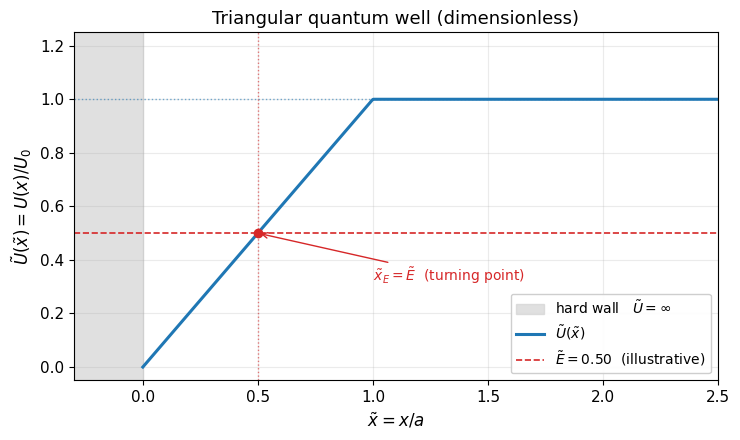

In [ ]:
fig, ax = plt.subplots() #the graph

x_show = np.linspace(0, 2.5, 600)
U_show = U_tilde(x_show) #evaluating potential

# the hard wall on the left
ax.axvspan(-0.3, 0, color='lightgray', alpha=0.7,
           label=r'hard wall   $\tilde U = \infty$')

# the well itself
ax.plot(x_show, U_show, color='C0', lw=2.2,
        label=r'$\tilde U(\tilde x)$')

# the barrier asymptote
ax.axhline(1.0, color='C0', ls=':', lw=1, alpha=0.6)

# turning-point illustration for a representative energy
E_demo = 0.5
ax.axhline(E_demo, color='C3', ls='--', lw=1.2,
           label=fr'$\tilde E = {E_demo:.2f}$  (illustrative)')
ax.axvline(E_demo, color='C3', ls=':', lw=1, alpha=0.6)
ax.plot([E_demo], [E_demo], 'o', color='C3', ms=6, zorder=5)
ax.annotate(r'$\tilde x_E = \tilde E$  (turning point)',
            xy=(E_demo, E_demo), xytext=(1.0, 0.32),
            arrowprops=dict(arrowstyle='->', color='C3', lw=1),
            color='C3', fontsize=10)

ax.set_xlim(-0.3, 2.5)
ax.set_ylim(-0.05, 1.25)
ax.set_xlabel(r'$\tilde x = x/a$')
ax.set_ylabel(r'$\tilde U(\tilde x) = U(x)/U_0$')
ax.set_title('Triangular quantum well (dimensionless)')
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()


**Interpretation.**
* The potential is zero at $\tilde x=0$, rises linearly to $1$ at $\tilde x=1$, and then stays
  flat at $1$.

---


## 2.6 The finite-difference Hamiltonian

### Derivation

The dimensionless Schrödinger equation

$$
-\frac{1}{2\beta^{2}}\,\frac{d^{2}\psi}{d\tilde x^{2}}
\;+\;\tilde U(\tilde x)\,\psi
\;=\;\tilde E\,\psi.
$$

We place a **uniform grid** of $N$ interior points on $(0,\tilde L)$,

$$
\tilde x_{j} \;=\; j\,h, \qquad j=1,2,\dots,N,
\qquad h \;=\; \frac{\tilde L}{N+1},
$$

The three-point
central-difference stencil for the second derivative is

$$
\left.\frac{d^{2}\psi}{d\tilde x^{2}}\right|_{\tilde x_{j}}
\;\approx\;
\frac{\psi_{j+1}-2\psi_{j}+\psi_{j-1}}{h^{2}},
$$

which has truncation error $O(h^{2})$. Substituting and rearranging:

$$
\underbrace{\left[\frac{1}{\beta^{2}h^{2}}+\tilde U(\tilde x_{j})\right]}_{\text{diagonal}}
\,\psi_{j}
\;+\;
\underbrace{\left(-\frac{1}{2\beta^{2}h^{2}}\right)}_{\text{off-diagonal}} \,(\psi_{j+1}+\psi_{j-1})
\;=\;\tilde E\,\psi_{j}.
$$

So $\mathcal{H}$ is a symmetric **tridiagonal** matrix with

$$
\mathcal{H}_{jj} \;=\; \frac{1}{\beta^{2}h^{2}} \;+\; \tilde U(\tilde x_{j}),
\qquad
\mathcal{H}_{j,j+1} \;=\; \mathcal{H}_{j+1,j} \;=\; -\frac{1}{2\beta^{2}h^{2}}.
$$

Boundary conditions enter for free:
* At $j=1$ the stencil uses $\psi_{0}=\psi(0)=0$ → **hard wall on the left**.
* At $j=N$ the stencil uses $\psi_{N+1}=\psi(\tilde L)=0$ → **box wall on the right**.



### Implementation


In [ ]:
def build_hamiltonian(N, L_tilde, beta2, U_func=U_tilde):
    '''
    diag    : (N,)   ndarray — main diagonal of H
    offdiag : (N-1,) ndarray — sub/super-diagonal of H
    x_grid  : (N,)   ndarray — grid coordinates x̃_j
    '''
    h = L_tilde / (N + 1)
    x_grid = np.arange(1, N + 1) * h

    kin_diag = 1.0 / (beta2 * h**2)         # +1/(β² h²)
    kin_off  = -0.5 / (beta2 * h**2)        # −1/(2 β² h²)

    diag    = kin_diag + U_func(x_grid)
    offdiag = np.full(N - 1, kin_off)

    return diag, offdiag, x_grid


## 2.7 The solver


We expose two convenience options:
* `n_states=None` → all eigenpairs (use for small $N$, debugging),
* `n_states=k`   → only the lowest $k$ eigenpairs (the normal use case
  for our problem, since we only care about the bound spectrum and the
  first few above-barrier states).


In [ ]:
def solve_triangular_well(N=N_DEFAULT, L_tilde=L_DEFAULT,
                            beta2=None, n_states=None,
                            U_func=U_tilde):
    '''
    Solve the dimensionless triangular-well eigenproblem.
    '''
    if beta2 is None:
        beta2 = beta2_default

    diag, offdiag, x_grid = build_hamiltonian(N, L_tilde, beta2, U_func)
    h = L_tilde / (N + 1)

    if n_states is None:
        E_tilde, psi = eigh_tridiagonal(diag, offdiag)
    else:
        # request only the lowest n_states eigenpairs
        n_states = min(n_states, N)
        E_tilde, psi = eigh_tridiagonal(
            diag, offdiag,
            select='i', select_range=(0, n_states - 1)
        )

    return E_tilde, psi, x_grid, h


## 2.8 First run — does it work?

Let us compute the lowest 8 eigenvalues with the default parameters
and print them. The diagnostic we look for:

* the values should be **real and ascending**,
* a small handful should sit **below the barrier** ($\tilde E<1$) —
  those are bound states,
* the rest sit above and are the "box-mode" approximations to the
  scattering continuum (Stage 1 §5.2).


In [ ]:
E_tilde, psi, x_grid, h = solve_triangular_well(
    N        = N_DEFAULT,
    L_tilde  = L_DEFAULT,
    beta2    = beta2_default,
    n_states = 8,
)

print(f"Solved on N = {N_DEFAULT} interior points, "
      f"box L̃ = {L_DEFAULT}, β² = {beta2_default:.3f}")
print(f"Grid spacing h = {h:.5f}  (a-units)")
print(f"")
print(f"{'n':>3s}  {'Ẽ_n':>10s}  {'E_n [meV]':>10s}   regime")
print(f"{'-'*42}")
for n, En in enumerate(E_tilde, start=1):
    En_meV  = En * U0_DEFAULT * 1000.0       # back to physical units
    regime  = 'BOUND' if En < 1.0 else 'above barrier'
    print(f"{n:>3d}  {En:>10.5f}  {En_meV:>10.3f}   {regime}")


Solved on N = 2000 interior points, box L̃ = 4.0, β² = 98.918
Grid spacing h = 0.00200  (a-units)

  n         Ẽ_n   E_n [meV]   regime
------------------------------------------
  1     0.40126     200.631   BOUND
  2     0.70148     350.738   BOUND
  3     0.94094     470.470   BOUND
  4     1.00532     502.660   above barrier
  5     1.02089     510.443   above barrier
  6     1.04581     522.905   above barrier
  7     1.07905     539.524   above barrier
  8     1.11947     559.734   above barrier


**Interpretation of the smoke test.**

* The first few levels are below $\tilde E=1$, hence below the
  physical barrier $U_0=0.5\,\mathrm{eV}$. These are the genuine bound
  states of the triangular well — exactly what the hard-wall model is
  supposed to produce.
* Their physical energies (rightmost column) are of order a few tens
  to a few hundred meV, consistent with confined-electron energies
  in a heterostructure.
* The remaining levels are above the barrier. They are not literal
  bound states of the infinite problem; they are *artefacts of the
  finite computational box*.



---


---
# Stage 3 — Spectrum, normalisation, plots, and the Airy cross-check


1. **Normalisation** — convert the raw eigenvectors into properly normalised
   wavefunctions ($\int|\psi|^{2}\,dx=1$).
2. **Headline plot** — the canonical visualisation of a 1D bound-state problem:
   $U(x)$ overlaid with the energy ladder $\{E_{n}\}$ and the corresponding
   $\psi_{n}(x)$ and $|\psi_{n}(x)|^{2}$ on their energy baselines.
3. **Quantitative diagnostics** — number of nodes, evanescent decay length,
   and the fraction of probability in the classically forbidden region.
4. **Airy-function cross-check** — construct the $2\times 2$ matching
   determinant with `scipy.special.airy`, locate its zeros with
   `scipy.optimize.brentq`, and compare with the finite-difference result.


## 3.1 Wavefunction normalisation

`scipy.linalg.eigh_tridiagonal` returns eigenvectors normalised in the
**discrete $\ell^{2}$ sense**: $\sum_{j}v_{j}^{2}=1$. We want the
**continuum normalisation** $\int|\psi(x)|^{2}\,dx=1$. On our uniform grid,
with the boundary values $\psi(0)=\psi(\tilde L)=0$, the trapezoidal rule
becomes simply

$$
\int_{0}^{\tilde L}\!|\tilde\psi(\tilde x)|^{2}\,d\tilde x
\;\approx\;
h\,\sum_{j=1}^{N}|\tilde\psi_{j}|^{2}
\;=\;1.
$$

So we obtain a properly normalised dimensionless wavefunction by dividing the
raw eigenvector by $\sqrt h$:

$$
\boxed{\;\tilde\psi_{j} \;=\; \frac{v_{j}}{\sqrt h}.\;}
$$

In **physical units** the wavefunction must integrate to 1 over $x$, so since
$dx = a\,d\tilde x$,

$$
\psi(x_{j}) \;=\; \frac{\tilde\psi(\tilde x_{j})}{\sqrt a} \;=\; \frac{v_{j}}{\sqrt{h\,a}}.
$$




In [ ]:
def normalise_wavefunctions(psi_raw, h):
    '''
    Convert the raw eigenvectors v_j (with Σ v_j² = 1) into wavefunctions
    properly normalised in the continuum sense (∫|ψ|² dx̃ = 1).  Also fixes
    the global sign so each ψ_n starts positive near x = 0.
    '''
    psi = psi_raw.copy() / np.sqrt(h)
    # sign convention: ψ_n > 0 in the first few grid points
    for j in range(psi.shape[1]):
        if np.sum(psi[:5, j]) < 0:
            psi[:, j] *= -1.0
    return psi


E_tilde, psi_raw, x_grid, h = solve_triangular_well(
    N        = N_DEFAULT,
    L_tilde  = L_DEFAULT,
    beta2    = beta2_default,
    n_states = 10,
)

psi_norm = normalise_wavefunctions(psi_raw, h)

# Quick check: every column should integrate to 1
norms = h * np.sum(psi_norm**2, axis=0)
print(f'Normalisation check — ∫|ψ_n|² dx̃ for n=1…{len(norms)}:')
print(np.array2string(norms, precision=6))
print(f'\nMax deviation from unity: {np.max(np.abs(norms - 1)):.3e}')


Normalisation check — ∫|ψ_n|² dx̃ for n=1…10:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Max deviation from unity: 2.554e-15


## 3.2 The headline plot

The standard pedagogical visualisation of a 1D bound-state problem places each
wavefunction on a horizontal baseline at its own energy. In one figure the
reader sees:

* the shape of the potential $\tilde U(\tilde x)$ (gray);
* the **spectrum** — horizontal dashed lines at each $\tilde E_{n}$;
* the **wavefunctions** $\psi_{n}(\tilde x)$ drawn around their baselines (left);
* the **probability densities** $|\psi_{n}(\tilde x)|^{2}$ likewise (right).

For the main figure we restrict to the **bound states** ($\tilde E_{n}<1$).
Above-barrier states are revisited in Stage 4 inside the bound$\leftrightarrow$
scattering toggle.


In [ ]:
# --- Select the bound subspectrum ---------------------------------------- #
bound_mask = E_tilde < 1.0
E_bound    = E_tilde[bound_mask]
psi_bound  = psi_norm[:, bound_mask]
n_bound    = len(E_bound)

print(f'Number of bound states (Ẽ < 1):   n_bound = {n_bound}')
print(f'Dimensionless bound energies:     Ẽ_n     = '
      f'{np.array2string(E_bound, precision=6)}')
print(f'Physical bound energies (meV):    E_n     = '
      f'{np.array2string(E_bound * U0_DEFAULT * 1000.0, precision=3)}')


Number of bound states (Ẽ < 1):   n_bound = 3
Dimensionless bound energies:     Ẽ_n     = [0.401261 0.701476 0.940939]
Physical bound energies (meV):    E_n     = [200.631 350.738 470.47 ]


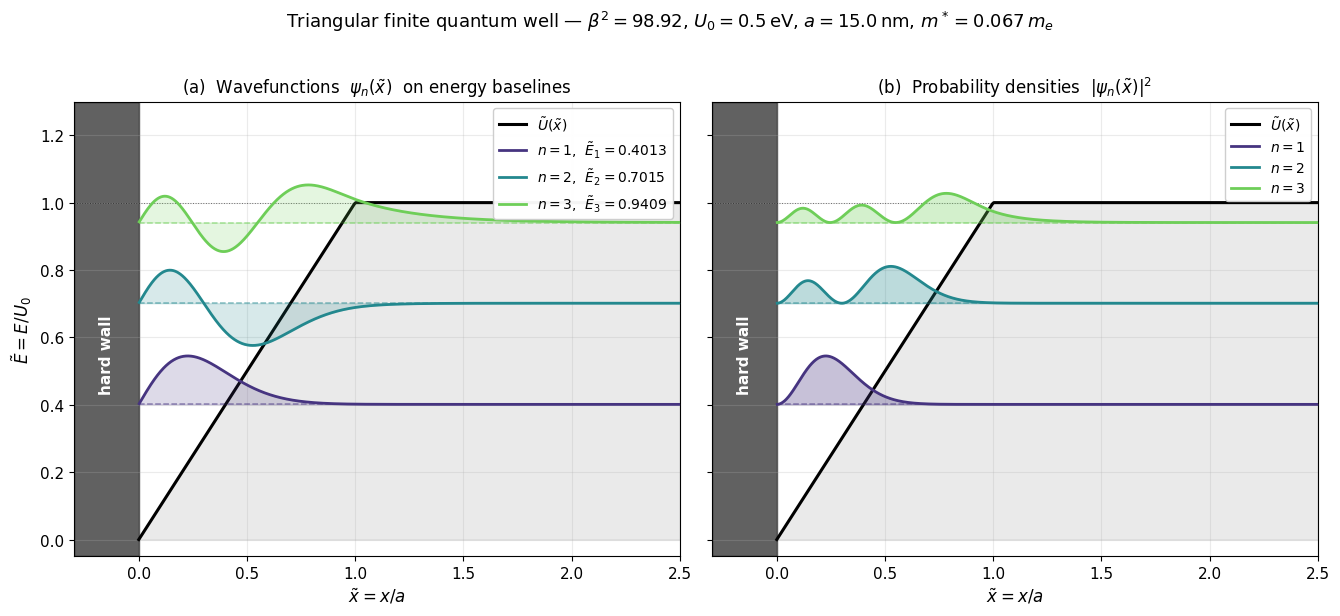

In [ ]:

x_max_disp = 2.5
mask_disp  = x_grid <= x_max_disp
x_plot     = x_grid[mask_disp]

# colours: a perceptually ordered viridis truncated to the readable midrange
colors = plt.cm.viridis(np.linspace(0.15, 0.78, n_bound))

gap_min     = np.min(np.diff(E_bound)) if n_bound > 1 else 0.3
psi_peak    = np.max(np.abs(psi_bound[mask_disp]))
prob_peak   = np.max(psi_bound[mask_disp]**2)
psi_scale   = 0.60 * gap_min / psi_peak
prob_scale  = 0.60 * gap_min / prob_peak


def draw_potential_backdrop(ax):
    '''Shared backdrop: hard wall, U(x̃), barrier asymptote.'''
    # Hard wall on the left
    ax.axvspan(-0.3, 0.0, color='black', alpha=0.62, zorder=1)
    ax.text(-0.15, 0.55, 'hard wall', ha='center', va='center',
            rotation=90, color='white', fontweight='bold', fontsize=11,
            zorder=2)
    # Potential
    x_fine = np.linspace(0, x_max_disp, 400)
    U_fine = U_tilde(x_fine)
    ax.fill_between(x_fine, 0, U_fine, color='gray', alpha=0.16, zorder=1)
    ax.plot(x_fine, U_fine, color='black', lw=2.2, zorder=3,
            label=r'$\tilde U(\tilde x)$')
    # Barrier-top reference
    ax.axhline(1.0, color='black', lw=0.7, ls=':', alpha=0.55, zorder=2)
    ax.set_xlim(-0.3, x_max_disp)
    ax.set_ylim(-0.05, 1.30)
    ax.set_xlabel(r'$\tilde x = x/a$', fontsize=12)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), sharey=True)

# Left panel: wavefunctions on baselines
ax1 = axes[0]
draw_potential_backdrop(ax1)
for n in range(n_bound):
    En   = E_bound[n]
    psin = psi_bound[mask_disp, n]
    ax1.hlines(En, 0, x_max_disp, colors=colors[n],
               linestyles='--', alpha=0.55, lw=1.1, zorder=2)
    ax1.fill_between(x_plot, En, En + psi_scale * psin,
                     color=colors[n], alpha=0.18, zorder=3)
    ax1.plot(x_plot, En + psi_scale * psin, color=colors[n], lw=2.0,
             label=rf'$n={n+1}$,  $\tilde E_{{{n+1}}}={En:.4f}$',
             zorder=4)
ax1.set_ylabel(r'$\tilde E = E/U_0$', fontsize=12)
ax1.set_title(r'(a)  Wavefunctions  $\psi_n(\tilde x)$  on energy baselines',
              fontsize=12)
ax1.legend(loc='upper right', fontsize=10, framealpha=0.96)

# Right panel: probability densities on baselines
ax2 = axes[1]
draw_potential_backdrop(ax2)
for n in range(n_bound):
    En    = E_bound[n]
    probn = psi_bound[mask_disp, n]**2
    ax2.hlines(En, 0, x_max_disp, colors=colors[n],
               linestyles='--', alpha=0.55, lw=1.1, zorder=2)
    ax2.fill_between(x_plot, En, En + prob_scale * probn,
                     color=colors[n], alpha=0.30, zorder=3)
    ax2.plot(x_plot, En + prob_scale * probn, color=colors[n], lw=2.0,
             label=rf'$n={n+1}$', zorder=4)
ax2.set_title(r'(b)  Probability densities  $|\psi_n(\tilde x)|^2$',
              fontsize=12)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.96)

fig.suptitle(
    rf'Triangular finite quantum well — '
    rf'$\beta^2={beta2_default:.2f}$, '
    rf'$U_0={U0_DEFAULT}\,\mathrm{{eV}}$, '
    rf'$a={A_DEFAULT}\,\mathrm{{nm}}$, '
    rf'$m^*={M_DEFAULT}\,m_e$',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()


### Interpretation of the headline figure

**Reading the plot.** The black curve is $\tilde U(\tilde x)$; the dark strip
on the left is the hard wall. Each dashed horizontal line is one eigenenergy
$\tilde E_{n}$, and the coloured curve drawn around it is the wavefunction
(left) or probability density (right) on that energy as a y-baseline. The
display scaling is purely cosmetic; the underlying $\psi_{n}$ is normalised to
$\int|\psi_{n}|^{2}\,d\tilde x=1$.



## 3.3 Quantitative diagnostics

For each bound state we compute:

* the **node count** (number of interior zeros of $\psi$);
* the **classical turning point** $\tilde x_E=\tilde E_n$;
* the **decay rate** $\tilde\kappa_n=\sqrt{2\beta^{2}(1-\tilde E_{n})}$
  and the corresponding **decay length** $1/\tilde\kappa_{n}$;
* the **probability inside the barrier**,
  $P_{\mathrm{barrier}}^{(n)}=\int_{a}^{\infty}|\psi_n|^{2}\,dx
  =h\sum_{j:\,\tilde x_j>1}|\tilde\psi_{j,n}|^{2}.$


In [ ]:
def count_nodes(psi_col, rel_threshold=1e-6):
    '''Count interior zeros (sign changes) of a 1D wavefunction sample,
    ignoring numerical noise below rel_threshold * max|ψ|.'''
    thresh = rel_threshold * np.max(np.abs(psi_col))
    signs  = np.sign(np.where(np.abs(psi_col) > thresh, psi_col, 0.0))
    nz     = signs[signs != 0]
    return int(np.sum(nz[:-1] != nz[1:]))


# Compute diagnostics for each bound state
kappa_t       = np.sqrt(2.0 * beta2_default * (1.0 - E_bound))
decay_len     = 1.0 / kappa_t
x_turn        = E_bound.copy()                     # x̃_E = Ẽ in dim'less form
in_barrier    = x_grid > 1.0
P_barrier     = np.array([
    h * np.sum(psi_bound[in_barrier, n] ** 2)
    for n in range(n_bound)
])
node_counts   = np.array([count_nodes(psi_bound[:, n]) for n in range(n_bound)])

# Pretty print
print(f'{"n":>3s}  {"Ẽ_n":>9s}  {"x̃_E":>7s}  {"nodes":>6s}'
      f'  {"κ̃_n":>7s}  {"1/κ̃_n":>8s}  {"P(barrier)":>11s}')
print('-' * 64)
for n in range(n_bound):
    print(f'{n+1:>3d}  {E_bound[n]:>9.5f}  {x_turn[n]:>7.4f}  '
          f'{node_counts[n]:>6d}  {kappa_t[n]:>7.3f}  '
          f'{decay_len[n]:>8.4f}  {P_barrier[n]:>11.4%}')


  n        Ẽ_n     x̃_E   nodes     κ̃_n    1/κ̃_n   P(barrier)
----------------------------------------------------------------
  1    0.40126   0.4013       0   10.884    0.0919      0.0004%
  2    0.70148   0.7015       1    7.685    0.1301      0.1687%
  3    0.94094   0.9409       2    3.418    0.2925     11.3581%


**Take-aways from the table.**

* **Node theorem confirmed.** Counts are $0,1,2$ in order — the
  expected $n-1$ pattern. The numerical wavefunctions are clean enough
  that the sign-change counter sees no spurious nodes from grid noise.
* **Turning point sweeps outward.** $\tilde x_{E}$ moves from
  $\sim 0.40$ for the ground state to $\sim 0.94$ for the highest
  bound state — most of the bound spectrum lives close to the top of
  the ramp.
* **Decay length and barrier probability grow with $n$.**



## 3.4 Analytical cross-check with Airy functions


### The matching determinant

There are three unknown coefficients:
* $C,\,D$ — the $\mathrm{Ai},\mathrm{Bi}$ amplitudes in the ramp
  ($0\le x\le a$);
* $F$ — the amplitude of the decaying exponential in $x>a$.

Three boundary conditions:

**(1) Hard wall**, $\psi(0)=0$:
$$
C\,\mathrm{Ai}(\xi_{0}) \;+\; D\,\mathrm{Bi}(\xi_{0}) \;=\; 0,
\qquad
\xi_{0} \;=\; -\tilde\alpha\,\tilde E,
\qquad
\tilde\alpha \;\equiv\; (2\beta^{2})^{1/3}.
$$

**(2) Continuity of $\psi$** at $x=a$:
$$
C\,\mathrm{Ai}(\xi_{a}) \;+\; D\,\mathrm{Bi}(\xi_{a}) \;=\; F,
\qquad
\xi_{a} \;=\; \tilde\alpha\,(1-\tilde E).
$$

**(3) Continuity of $\psi'$** at $x=a$:
$$
\tilde\alpha\bigl[C\,\mathrm{Ai}'(\xi_{a}) + D\,\mathrm{Bi}'(\xi_{a})\bigr]
\;=\; -\,\tilde\kappa\,F,
\qquad
\tilde\kappa \;\equiv\; \sqrt{2\beta^{2}(1-\tilde E)}.
$$


Eliminate $F$ by substituting (2) into (3):

$$
\tilde\alpha\bigl[C\,\mathrm{Ai}'(\xi_{a}) + D\,\mathrm{Bi}'(\xi_{a})\bigr]
\;=\;
-\tilde\kappa\,\bigl[C\,\mathrm{Ai}(\xi_{a}) + D\,\mathrm{Bi}(\xi_{a})\bigr],
$$

i.e.

$$
C\,\bigl[\tilde\alpha\,\mathrm{Ai}'(\xi_{a}) + \tilde\kappa\,\mathrm{Ai}(\xi_{a})\bigr]
\;+\;
D\,\bigl[\tilde\alpha\,\mathrm{Bi}'(\xi_{a}) + \tilde\kappa\,\mathrm{Bi}(\xi_{a})\bigr]
\;=\;0.
$$

Combined with (1) we have a $2\times 2$ homogeneous linear system for $(C,D)$.
A non-trivial solution exists iff the determinant vanishes:

$$
\boxed{\;
M(\tilde E)\;\equiv\;
\mathrm{Ai}(\xi_{0})\,\bigl[\tilde\alpha\,\mathrm{Bi}'(\xi_{a}) + \tilde\kappa\,\mathrm{Bi}(\xi_{a})\bigr]
\;-\;
\mathrm{Bi}(\xi_{0})\,\bigl[\tilde\alpha\,\mathrm{Ai}'(\xi_{a}) + \tilde\kappa\,\mathrm{Ai}(\xi_{a})\bigr]
\;=\;0.\;}
$$

This is the **exact transcendental eigenvalue equation** for the finite
triangular well. Its roots in $\tilde E\in(0,1)$ are the bound-state energies.

`scipy.special.airy(ξ)` returns the four-tuple
$\bigl(\mathrm{Ai}(\xi),\,\mathrm{Ai}'(\xi),\,\mathrm{Bi}(\xi),\,\mathrm{Bi}'(\xi)\bigr)$
in a single call, so $M(\tilde E)$ is just a few lines of code.



In [ ]:
def matching_det(E_tilde, beta2):

    alpha_t = (2.0 * beta2) ** (1.0 / 3.0)
    kappa_t = np.sqrt(2.0 * beta2 * (1.0 - E_tilde))
    xi_0    = -alpha_t * E_tilde
    xi_a    =  alpha_t * (1.0 - E_tilde)

    Ai0, Aip0, Bi0, Bip0 = airy(xi_0)
    Aia, Aipa, Bia, Bipa = airy(xi_a)

    return (Ai0 * (alpha_t * Bipa + kappa_t * Bia)
          - Bi0 * (alpha_t * Aipa + kappa_t * Aia))


# Step 1: tabulate on a fine grid
E_scan = np.linspace(1e-4, 1.0 - 1e-4, 4001)
M_scan = matching_det(E_scan, beta2_default)

# Step 2: locate sign changes
sign_changes = np.where(np.diff(np.sign(M_scan)) != 0)[0]

# Step 3: refine with brentq
E_analytical = np.array([
    brentq(matching_det, E_scan[i], E_scan[i+1], args=(beta2_default,),
           xtol=1e-12, rtol=1e-12)
    for i in sign_changes
])

print(f'Found {len(E_analytical)} bound-state roots in Ẽ ∈ (0, 1)')
print(f'Analytical eigenvalues:')
for n, En in enumerate(E_analytical, start=1):
    print(f'  Ẽ_{n} = {En:.9f}   '
          f'|M(Ẽ_{n})| = {abs(matching_det(En, beta2_default)):.2e}')


Found 3 bound-state roots in Ẽ ∈ (0, 1)
Analytical eigenvalues:
  Ẽ_1 = 0.401263341   |M(Ẽ_1)| = 1.54e-11
  Ẽ_2 = 0.701482492   |M(Ẽ_2)| = 4.67e-15
  Ẽ_3 = 0.940949664   |M(Ẽ_3)| = 1.61e-15


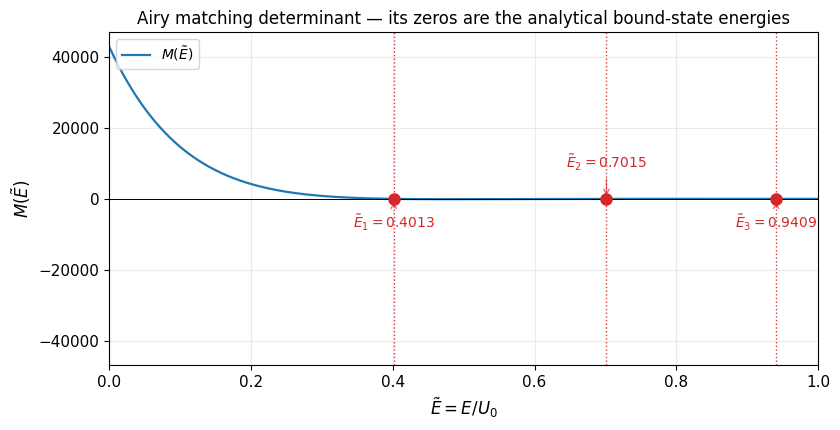

In [ ]:
# Plot M(Ẽ) over the bound interval and mark the zeros.
fig, ax = plt.subplots(figsize=(8.5, 4.4))

ax.plot(E_scan, M_scan, color='C0', lw=1.6, label=r'$M(\tilde E)$')
ax.axhline(0.0, color='black', lw=0.7)

ymax_abs = np.max(np.abs(M_scan)) * 1.1
ax.set_ylim(-ymax_abs, ymax_abs)

for n, En in enumerate(E_analytical, start=1):
    ax.axvline(En, color='C3', ls=':', lw=1.0, alpha=0.9)
    ax.plot([En], [0], 'o', color='C3', ms=8, zorder=5)
    ax.annotate(rf'$\tilde E_{n}={En:.4f}$',
                xy=(En, 0),
                xytext=(En, 0.18 * ymax_abs * (-1)**n),
                ha='center', fontsize=10, color='C3',
                arrowprops=dict(arrowstyle='->', color='C3', lw=0.9, alpha=0.7))

ax.set_xlabel(r'$\tilde E = E/U_0$', fontsize=12)
ax.set_ylabel(r'$M(\tilde E)$', fontsize=12)
ax.set_title('Airy matching determinant — its zeros are the analytical bound-state energies',
             fontsize=12)
ax.set_xlim(0.0, 1.0)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


## 3.5 Three-way comparison: numerical, analytical, and idealised Airy

We now bring three independent calculations side-by-side.

| Symbol | What it is |
|--------|------------|
| $\tilde E_{n}^{\mathrm{FD}}$         | Finite-difference eigenvalue  |
| $\tilde E_{n}^{\mathrm{Ai}}$         | Exact root of $M(\tilde E)=0$     |
| $\tilde E_{n}^{\mathrm{Airy}\,\infty}$ | *Idealised* Airy result for an infinitely tall ramp (no flattening) |

The idealised formula is what one gets if the linear potential $U=(U_{0}/a)\,x$
is *not* truncated at $x=a$. Then in $x>0$ the only square-integrable solution
is $\psi(x)=N\,\mathrm{Ai}(\alpha(x-x_E))$ (because $\mathrm{Bi}$ grows), and
the hard wall fixes $\mathrm{Ai}(-\alpha x_E)=0$. The zeros of $\mathrm{Ai}$,
labelled $a_n<0$, give

$$
\boxed{\;\tilde E_{n}^{\mathrm{Airy}\,\infty} \;=\; \frac{|a_{n}|}{(2\beta^{2})^{1/3}}.\;}
$$

The first few Airy zeros are
$a_1\approx-2.3381$, $a_2\approx-4.0879$, $a_3\approx-5.5206$, …

Two differences are of interest:
* $\Delta^{\mathrm{FD}}_{n}=|\tilde E_{n}^{\mathrm{FD}}-\tilde E_{n}^{\mathrm{Ai}}|$
  — a measure of the **numerical method** (should be small, $O(h^{2})$).
* $\Delta^{\mathrm{barrier}}_{n}=|\tilde E_{n}^{\mathrm{Ai}}-\tilde E_{n}^{\mathrm{Airy}\,\infty}|$
  — a measure of the **finite-barrier correction** (should be tiny for low $n$
  and grow rapidly as $\tilde E_{n}\to 1$).


In [ ]:
from scipy.special import ai_zeros        # imported locally for clarity

# Compute idealised Airy energies (one extra to show the next would-be level)
n_request = n_bound + 1
a_zeros, _, _, _ = ai_zeros(n_request)            # a_zeros are negative
E_airy_ideal = np.abs(a_zeros) / (2.0 * beta2_default) ** (1.0/3.0)

# Print the comparison table
print(f'{"n":>3s} |'
      f'{"Ẽ_FD":>12s}  {"Ẽ_Airy_match":>14s}  {"|Δ_FD|":>10s}  |'
      f'{"Ẽ_Airy_ideal":>14s}  {"|Δ_barrier|":>12s}')
print('-' * 81)
for n in range(n_bound):
    E_FD     = E_bound[n]
    E_ai     = E_analytical[n]
    d_FD     = abs(E_FD - E_ai)
    E_aiinf  = E_airy_ideal[n]
    d_bar    = abs(E_ai - E_aiinf)
    print(f'{n+1:>3d} |'
          f'{E_FD:>12.7f}  {E_ai:>14.7f}  {d_FD:>10.2e}  |'
          f'{E_aiinf:>14.7f}  {d_bar:>12.2e}')

# Show the next idealised Airy level — generally above the barrier
nxt = E_airy_ideal[n_bound]
flag = '  (above barrier — escapes the finite well)' if nxt > 1.0 else ''
print(f'\nNext idealised Airy level (would-be n={n_bound+1}): '
      f'Ẽ = {nxt:.4f}{flag}')


  n |        Ẽ_FD    Ẽ_Airy_match      |Δ_FD|  |  Ẽ_Airy_ideal   |Δ_barrier|
---------------------------------------------------------------------------------
  1 |   0.4012612       0.4012633    2.12e-06  |     0.4012635      1.64e-07
  2 |   0.7014760       0.7014825    6.47e-06  |     0.7015695      8.70e-05
  3 |   0.9409393       0.9409497    1.03e-05  |     0.9474326      6.48e-03

Next idealised Airy level (would-be n=4): Ẽ = 1.1647  (above barrier — escapes the finite well)


### Discussion of the comparison


1. **Numerical (FD) vs analytical (Airy matching).**
   $\Delta^{\mathrm{FD}}_{n}$ is $\lesssim 10^{-4}$ for $N=2000$, consistent
   with the $O(h^{2})$ truncation of the three-point stencil
   ($h\approx 2\times 10^{-3}$, so $h^{2}\sim 4\times 10^{-6}$ ).

2. **Analytical (finite barrier) vs idealised (infinite ramp) Airy.**
   $\Delta^{\mathrm{barrier}}_{n}$ is *tiny* for the lowest state and
   grows by many orders of magnitude across the bound spectrum. The
   ground state effectively does not "see" the saturation at $x=a$
   because its wavefunction has already decayed to negligible
   amplitude before reaching the corner.

#### Why does the idealised Airy formula work so well for low $n$?

The idealised formula treats the linear potential as if it kept
rising forever ($U\to\infty$ as $x\to\infty$). The exact problem
*truncates* the ramp at $U=U_{0}$. Why is the idealisation good?

Because in the deep-bound limit the wavefunction has decayed to
*virtually zero* by the time it reaches the saturation point. The
relevant suppression factor is the Airy asymptotic
$$
\mathrm{Ai}(\xi_{a}) \;\sim\;
\frac{1}{2\sqrt{\pi}}\,\xi_{a}^{-1/4}\,
\exp\!\left(-\tfrac{2}{3}\,\xi_{a}^{3/2}\right),
\qquad
\xi_{a}=(2\beta^{2})^{1/3}(1-\tilde E_{n}).
$$
For the ground state of our default well, $\xi_{a}\approx 3.5$ and
$\exp(-\tfrac{2}{3}\,\xi_{a}^{3/2})\approx e^{-4.4}\approx 10^{-2}$;
the wavefunction amplitude at $x=a$ is two orders of magnitude smaller
than its peak. Whether the ramp continues or saturates is then
practically invisible to the wavefunction — and to the eigenvalue.

For the highest bound state, $\xi_{a}$ is much smaller (close to
zero), the Airy suppression is gone, and the *infinite-ramp*
idealisation fails. Physically: this state extends visibly into the
barrier, and the difference between "ramp continues" and "ramp
plateaus" is real.

#### Two qualitative consequences

* **The Airy formula
  $\tilde E_{n}^{\mathrm{Airy}\,\infty}=|a_{n}|/(2\beta^{2})^{1/3}$
  is an essentially exact predictor for deeply bound states.**
* **The number of bound states is approximately
  $n_{\mathrm{bound}}\approx\lfloor(2\beta^{2})^{1/3}/a_{1}\rfloor$,**
  i.e., the largest $n$ for which $\tilde E_{n}^{\mathrm{Airy}\,\infty}<1$.
  For $\beta^{2}\approx 99$ this gives roughly
  $5.83/2.338\approx 2.5$, so two or three bound states — matching what
  we find.




---
# Stage 4 — Interactivity, parameter studies, and final remarks

This stage covers:

1. **An interactive explorer** built with `ipywidgets`. Sliders for
   $U_{0},\ a,\ m^*,\ N$, plus a mode toggle for bound vs scattering display.
2. **A bound$\leftrightarrow$scattering visualisation** that shows how
   above-barrier states are represented as box modes.
3. **Convergence in $N$** — confirms the $O(h^{2})$ behaviour predicted by
   the three-point stencil.
4. **Sensitivity to box size $\tilde L$** — checks that the bound levels
   are insensitive to the artificial right wall.
5. **Parameter study** of $n_{\text{bound}}(\beta^{2})$ — a "phase diagram"
   showing how levels enter the spectrum as the well deepens.
6. **Final discussion** of numerical accuracy, limitations, and possible
   extensions.




## 4.1 The interactive explorer

The widget below packages everything we have built into a single panel:

* **Sliders.** $U_{0}$ (barrier height in eV), $a$ (ramp width in nm),
  $m^*/m_e$ (effective mass ratio), $N$ (interior grid points), `n_show`
  (how many levels to display).
* **Mode toggle.** `'bound'` shows the truly bound spectrum
  ($\tilde E_{n}<1$). `'scattering'` extends the display above the
  barrier into the box modes that approximate scattering states.
* **Live readout.** $\beta^{2}$, the Airy length scale $(2\beta^{2})^{1/3}$,
  the number of bound states, and a compact table of $\tilde E_{n}$ in
  both dimensionless and physical units.



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def make_well_figure(U0_eV, a_nm, m_ratio, N, n_show, mode, L_tilde=4.0):
    '''
    Solve the triangular well with the given physical parameters and produce
    the headline figure (potential, energy levels, ψ_n, |ψ_n|²).
    '''
    # --- solve --- #
    beta2 = beta_squared(U0_eV, a_nm, m_ratio)
    E_t, psi_raw, x_g, h_ = solve_triangular_well(
        N=N, L_tilde=L_tilde, beta2=beta2, n_states=max(n_show, 4)
    )
    psi = normalise_wavefunctions(psi_raw, h_)

    if mode == 'bound':
        keep = E_t < 1.0
        E_t  = E_t[keep]
        psi  = psi[:, keep]
    n_plot = min(n_show, len(E_t))
    E_plot   = E_t[:n_plot]
    psi_plot = psi[:, :n_plot]

    # --- plot --- #
    x_max_disp = max(2.5, 1.0 + 0.5 * np.sqrt(max(1.0, 1.0 / max(beta2, 1e-3))))
    mask_d = x_g <= x_max_disp
    x_p    = x_g[mask_d]

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharey=True)

    # cosmetic scaling
    if n_plot >= 2:
        gap_min = np.min(np.diff(E_plot))
    else:
        gap_min = 0.25
    gap_min   = max(gap_min, 0.05)            # never collapse to nothing
    psi_peak  = max(np.max(np.abs(psi_plot[mask_d])), 1e-12)
    prob_peak = max(np.max(psi_plot[mask_d]**2), 1e-12)
    psi_scale, prob_scale = 0.55*gap_min/psi_peak, 0.55*gap_min/prob_peak

    colors = plt.cm.viridis(np.linspace(0.15, 0.78, max(n_plot, 1)))

    ymax = max(E_plot[-1] + 0.7*gap_min, 1.15) if n_plot else 1.15
    for ax in axes:
        ax.axvspan(-0.3, 0, color='black', alpha=0.62)
        ax.text(-0.15, 0.5*ymax, 'hard wall', ha='center', va='center',
                rotation=90, color='white', fontweight='bold', fontsize=10)
        xs = np.linspace(0, x_max_disp, 400)
        ax.fill_between(xs, 0, U_tilde(xs), color='gray', alpha=0.16)
        ax.plot(xs, U_tilde(xs), color='black', lw=2.0)
        ax.axhline(1.0, color='black', lw=0.6, ls=':', alpha=0.55)
        ax.set_xlim(-0.3, x_max_disp)
        ax.set_ylim(-0.05, ymax)
        ax.set_xlabel(r'$\tilde x = x/a$')

    for n in range(n_plot):
        En  = E_plot[n]
        psn = psi_plot[mask_d, n]
        col = colors[n]
        bound_flag = ' (bound)' if En < 1.0 else ' (above barrier)'
        for k, ax in enumerate(axes):
            ax.hlines(En, 0, x_max_disp, colors=col, ls='--',
                      alpha=0.55, lw=1.0)
            if k == 0:
                y = En + psi_scale * psn
                ax.fill_between(x_p, En, y, color=col, alpha=0.18)
                ax.plot(x_p, y, color=col, lw=1.8,
                        label=rf'$n={n+1}$,  $\tilde E={En:.3f}${bound_flag}')
            else:
                y = En + prob_scale * psn**2
                ax.fill_between(x_p, En, y, color=col, alpha=0.30)
                ax.plot(x_p, y, color=col, lw=1.8, label=rf'$n={n+1}$')

    axes[0].set_ylabel(r'$\tilde E = E/U_0$')
    axes[0].set_title(r'$\psi_n(\tilde x)$ on energy baselines')
    axes[1].set_title(r'$|\psi_n(\tilde x)|^2$ on energy baselines')
    axes[0].legend(loc='upper right', fontsize=9, framealpha=0.95)
    axes[1].legend(loc='upper right', fontsize=9, framealpha=0.95)

    n_bound_lbl = int(np.sum(E_t < 1.0)) if mode == 'bound' else '-'
    fig.suptitle(
        rf'$U_0={U0_eV:.3f}\,\mathrm{{eV}}$,  '
        rf'$a={a_nm:.1f}\,\mathrm{{nm}}$,  '
        rf'$m^*={m_ratio:.3f}\,m_e$  '
        rf'$\Rightarrow\ \beta^2={beta2:.2f}$  '
        rf'($n_\mathrm{{bound}}={n_bound_lbl}$,  '
        rf'mode = {mode})',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    plt.show()

    # textual readout
    print(f'β² = {beta2:.4f}     '
          f'(2β²)^(1/3) = {(2*beta2)**(1/3):.4f}   '
          f'(Airy scale)')
    print(f'Grid spacing h = {L_tilde/(N+1):.5f}    (in units of a)')
    print()
    print(f'{"n":>3s}  {"Ẽ_n":>9s}  {"E_n [meV]":>11s}   {"regime":<14s}')
    print('-' * 46)
    for n, En in enumerate(E_plot, start=1):
        regime = 'BOUND' if En < 1.0 else 'above barrier'
        print(f'{n:>3d}  {En:>9.5f}  {En*U0_eV*1000.0:>11.3f}   {regime:<14s}')


In [ ]:
# Build the widget controls.

style  = {'description_width': '110px'}
layout = widgets.Layout(width='420px')

U0_w = widgets.FloatSlider(value=U0_DEFAULT, min=0.05, max=2.0, step=0.01,
        description=r'$U_0$ [eV]', continuous_update=False,
        style=style, layout=layout)
a_w  = widgets.FloatSlider(value=A_DEFAULT, min=2.0, max=40.0, step=0.5,
        description=r'$a$ [nm]', continuous_update=False,
        style=style, layout=layout)
m_w  = widgets.FloatSlider(value=M_DEFAULT, min=0.02, max=1.0, step=0.01,
        description=r'$m^*/m_e$', continuous_update=False,
        style=style, layout=layout)
N_w  = widgets.IntSlider(value=N_DEFAULT, min=200, max=4000, step=100,
        description=r'$N$ (grid pts)', continuous_update=False,
        style=style, layout=layout)
nshow_w = widgets.IntSlider(value=4, min=1, max=10, step=1,
        description='states shown', continuous_update=False,
        style=style, layout=layout)
mode_w  = widgets.ToggleButtons(
        options=[('bound only', 'bound'), ('include scattering', 'scattering')],
        value='bound',
        description='display:', style=style,
        layout=widgets.Layout(width='420px'))

ui = widgets.VBox([
    widgets.HBox([U0_w, a_w]),
    widgets.HBox([m_w, N_w]),
    widgets.HBox([nshow_w, mode_w]),
])

out = widgets.interactive_output(make_well_figure, {
    'U0_eV': U0_w, 'a_nm': a_w, 'm_ratio': m_w,
    'N':     N_w,  'n_show': nshow_w, 'mode': mode_w,
})

display(ui, out)


Output()

## 4.2 Bound vs scattering — what changes?

In the **bound mode** above, only states with $\tilde E_{n}<1$ are shown.
These are *genuine* bound states: their energies are insensitive to the
right wall position $\tilde L$, and the wavefunctions
decay exponentially in the barrier region. The hard wall at $x=0$ plus the
exponential decay at infinity are physical confinements.

In the **scattering mode**, we also display levels with $\tilde E_{n}>1$.
These are *box modes*: they live in the artificial cavity $0<x<\tilde L$ and
their energies depend on $\tilde L$. In the limit $\tilde L\to\infty$ they
densify into a continuum, which is the proper scattering spectrum of the
infinite problem. What survives the limit is not the individual eigenvalues
but the *local density of states* and the *transmission/reflection
coefficients*.

To make the distinction concrete, the side-by-side plot below shows the
spectrum at two different box sizes. Bound-state energies (below the dotted
line) coincide; above-barrier levels move noticeably as $\tilde L$ changes.


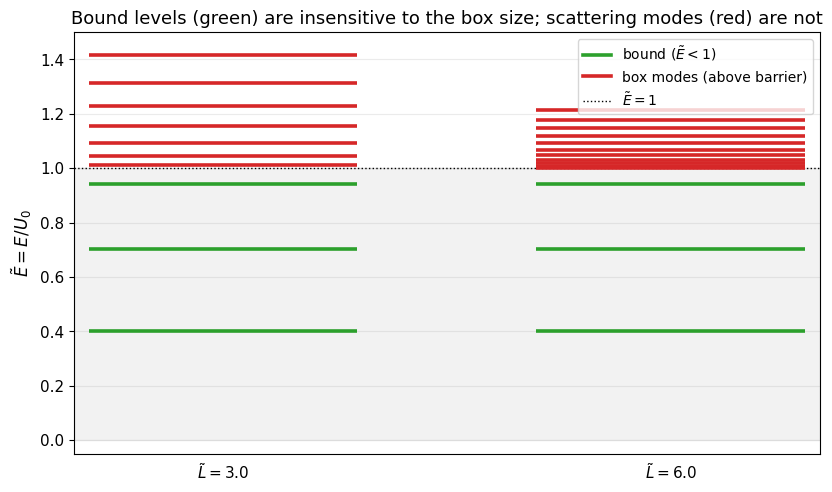

Maximum shift of bound  levels between L̃=3.0 and L̃=6.0: 1.78e-05
Maximum shift of scatt. levels between L̃=3.0 and L̃=6.0: 7.24e-01


In [ ]:
# Compare spectra at two different box sizes
N_cmp = 2000
L_pair = (3.0, 6.0)
E_pair = []
for L_ in L_pair:
    E_, _, _, _ = solve_triangular_well(N=N_cmp, L_tilde=L_,
                                        beta2=beta2_default, n_states=14)
    E_pair.append(E_)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.axhspan(0, 1, color='gray', alpha=0.10, zorder=0)
ax.axhline(1.0, color='black', lw=1.0, ls=':', label=r'barrier top ($\tilde E=1$)')

for i, (L_, E_) in enumerate(zip(L_pair, E_pair)):
    x_anchor = 0.2 + i*0.6
    for n, En in enumerate(E_):
        col = 'C2' if En < 1.0 else 'C3'
        ax.hlines(En, x_anchor-0.18, x_anchor+0.18,
                  colors=col, lw=2.6)

    ax.text(x_anchor, -0.06, rf'$\tilde L={L_}$', ha='center',
            transform=ax.get_xaxis_transform(), fontsize=11)

ax.set_xlim(0, 1.0)
ax.set_xticks([])
ax.set_ylim(-0.05, 1.5)
ax.set_ylabel(r'$\tilde E = E/U_0$')
ax.set_title('Bound levels (green) are insensitive to the box size; '
             'scattering modes (red) are not')
# legend
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='C2', lw=2.6, label=r'bound ($\tilde E<1$)'),
    Line2D([0],[0], color='C3', lw=2.6, label=r'box modes (above barrier)'),
    Line2D([0],[0], color='black', ls=':', lw=1.0, label=r'$\tilde E = 1$'),
], loc='upper right')
plt.tight_layout()
plt.show()

# Compute and report the maximum shift of bound vs scattering levels
n_bound_cmp = min(int(np.sum(E_pair[0]<1.0)), int(np.sum(E_pair[1]<1.0)))
shifts_bound  = np.abs(E_pair[0][:n_bound_cmp] - E_pair[1][:n_bound_cmp])
shifts_scatt  = np.abs(E_pair[0][n_bound_cmp:] - E_pair[1][n_bound_cmp:len(E_pair[0])])
print(f'Maximum shift of bound  levels between L̃={L_pair[0]} and L̃={L_pair[1]}: '
      f'{np.max(shifts_bound):.2e}')
print(f'Maximum shift of scatt. levels between L̃={L_pair[0]} and L̃={L_pair[1]}: '
      f'{np.max(shifts_scatt):.2e}')


**What the plot shows.** The bound levels (green) line up between the two
box sizes; the box modes (red) shift by amounts of order the level spacing.
This is the practical signature of "discrete vs continuous": if a level moves
when you change the box, it is *not* a real eigenstate of the infinite-domain
problem.


## 4.3 Convergence study: error vs grid resolution

The three-point central-difference stencil for $d^{2}/d\tilde x^{2}$ has
$O(h^{2})$ truncation error, so eigenvalues should converge as $h^{2}$
(equivalently $N^{-2}$) towards the exact analytical values from §3.4.

We use the Airy matching result as the **reference** and plot
$\Delta\tilde E_{n}(N)=|\tilde E_{n}^{\mathrm{FD}}(N)-\tilde E_{n}^{\mathrm{Ai}}|$
as a log–log plot. Slope $-2$ would confirm the expected scaling.


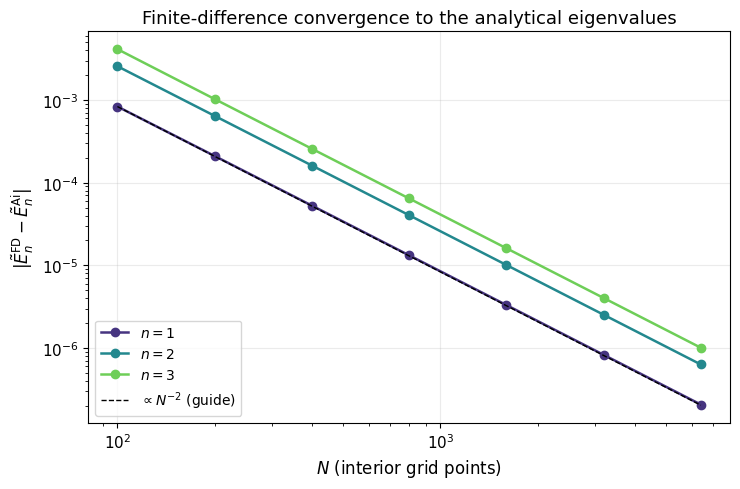

Empirical convergence exponents (expect ≈ -2):
  n=1: slope = -1.996
  n=2: slope = -1.997
  n=3: slope = -1.999


In [ ]:
# Convergence: for each of several N values, solve the FD eigenproblem
# and record the deviation of each bound-state energy from the Airy result.

N_list = [100, 200, 400, 800, 1600, 3200, 6400]
E_ref  = E_analytical                    # 3 values from §3.4

errors = np.zeros((len(N_list), len(E_ref)))
for i, N_ in enumerate(N_list):
    E_, _, _, _ = solve_triangular_well(
        N=N_, L_tilde=L_DEFAULT, beta2=beta2_default,
        n_states=len(E_ref),
    )
    errors[i] = np.abs(E_[:len(E_ref)] - E_ref)

fig, ax = plt.subplots(figsize=(7.5, 5.0))
colors_n = plt.cm.viridis(np.linspace(0.15, 0.78, len(E_ref)))
for n in range(len(E_ref)):
    ax.loglog(N_list, errors[:, n], 'o-', color=colors_n[n], lw=1.8,
              label=rf'$n={n+1}$')

# reference slope-2 guide
N_arr = np.array(N_list, dtype=float)
guide = errors[0, 0] * (N_arr[0]/N_arr)**2
ax.loglog(N_arr, guide, 'k--', lw=1.0, label=r'$\propto N^{-2}$ (guide)')

ax.set_xlabel(r'$N$ (interior grid points)')
ax.set_ylabel(r'$|\tilde E_n^{\mathrm{FD}} - \tilde E_n^{\mathrm{Ai}}|$')
ax.set_title('Finite-difference convergence to the analytical eigenvalues')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Estimate the empirical exponent
slopes = []
for n in range(len(E_ref)):
    p = np.polyfit(np.log(N_arr), np.log(errors[:, n]), 1)
    slopes.append(p[0])
print(f'Empirical convergence exponents (expect ≈ -2):')
for n, s in enumerate(slopes, start=1):
    print(f'  n={n}: slope = {s:.3f}')



At the default $N=2000$ the error is already a few parts in $10^{6}$, which
is far below any physically meaningful uncertainty. There is no reason to go
higher than this for everyday use; we use the convergence study purely as
validation.


## 4.4 Sensitivity to the box size $\tilde L$

The right wall at $\tilde x=\tilde L$ is computational, not physical. The
bound spectrum should be **insensitive** to $\tilde L$ once $\tilde L$ is
large enough for the slowest-decaying bound state to have died out before
hitting the wall.

We expect:
* the dependence to be **exponentially small** in $\tilde L$, with rate
  $\tilde\kappa_{n}$ — the decay rate of the slowest bound state;
* therefore the highest bound state ($\tilde\kappa_{n}$ smallest) sets the
  required $\tilde L$.


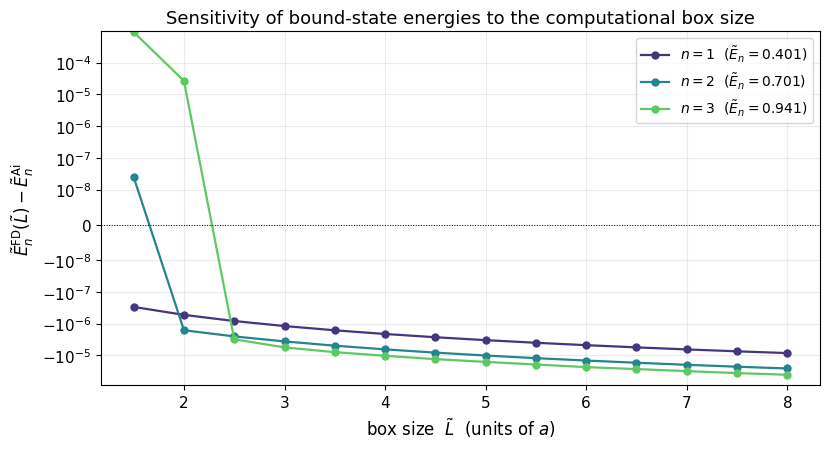


For each bound state, deviation from the L̃=8 value:
  L̃       |Δ_1|       |Δ_2|       |Δ_3|
------------------------------------------
 1.5    8.19e-06    2.59e-05    9.52e-04
 2.0    7.96e-06    2.43e-05    6.72e-05
 2.5    7.66e-06    2.34e-05    3.77e-05
 3.0    7.29e-06    2.22e-05    3.52e-05
 3.5    6.86e-06    2.09e-05    3.29e-05
 4.0    6.36e-06    1.94e-05    3.05e-05
 4.5    5.80e-06    1.77e-05    2.77e-05
 5.0    5.17e-06    1.58e-05    2.47e-05
 5.5    4.48e-06    1.36e-05    2.14e-05
 6.0    3.71e-06    1.13e-05    1.74e-05
 6.5    2.88e-06    8.79e-06    1.38e-05
 7.0    1.99e-06    6.06e-06    9.50e-06
 7.5    1.03e-06    3.12e-06    4.66e-06
 8.0    0.00e+00    0.00e+00    0.00e+00


In [ ]:
# Vary L̃ and watch the bound levels
L_list = np.linspace(1.5, 8.0, 14)
E_vs_L = []
for L_ in L_list:
    E_, _, _, _ = solve_triangular_well(
        N=2000, L_tilde=L_, beta2=beta2_default, n_states=4,
    )
    E_vs_L.append(E_[:3])
E_vs_L = np.array(E_vs_L)

fig, ax = plt.subplots(figsize=(8.4, 4.6))
for n in range(3):
    ax.plot(L_list, E_vs_L[:, n] - E_analytical[n], 'o-',
            color=plt.cm.viridis(0.15 + 0.3*n), lw=1.6, ms=5,
            label=rf'$n={n+1}$  ($\tilde E_n={E_analytical[n]:.3f}$)')
ax.axhline(0.0, color='black', lw=0.7, ls=':')
ax.set_xlabel(r'box size  $\tilde L$  (units of $a$)')
ax.set_ylabel(r'$\tilde E_n^{\mathrm{FD}}(\tilde L) - \tilde E_n^{\mathrm{Ai}}$')
ax.set_yscale('symlog', linthresh=1e-8)
ax.set_title(r'Sensitivity of bound-state energies to the computational box size')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Numbers
print(f'\nFor each bound state, deviation from the L̃=8 value:')
print(f'{"L̃":>4s}  '
      f'{"|Δ_1|":>10s}  {"|Δ_2|":>10s}  {"|Δ_3|":>10s}')
print('-' * 42)
ref = E_vs_L[-1]
for i, L_ in enumerate(L_list):
    d = np.abs(E_vs_L[i] - ref)
    print(f'{L_:>4.1f}  {d[0]:>10.2e}  {d[1]:>10.2e}  {d[2]:>10.2e}')


**Take-aways.**

* The lowest state is rock-solid: by $\tilde L\approx 2$ its energy has
  converged to many decimals, because its tail $e^{-\tilde\kappa_{1}\tilde x}$
  has $\tilde\kappa_{1}\sim 10$ and is dead long before the wall.
* The highest bound state takes longer — its decay rate
  $\tilde\kappa_{3}\sim 3$ means the tail extends visibly into the
  computational domain. By $\tilde L=4$ (our default) it has converged
  to $\sim 10^{-5}$, well below the FD discretisation error.
* For very shallow wells with $\tilde E_{n}\to 1$, $\tilde\kappa_{n}\to 0$
  and the required $\tilde L$ diverges. In practice the threshold one would
  reach in slider play is well-handled by $\tilde L=4$ for the default
  parameter range.


## 4.5 How does the number of bound states depend on $\beta^{2}$?

The single dimensionless parameter $\beta^{2}=mU_{0}a^{2}/\hbar^{2}$ controls
the entire spectrum (§6). A useful "phase diagram" is the plot of the
*bound-state count* $n_{\mathrm{bound}}(\beta^{2})$.

Two things to look for:
* a **staircase** structure as new bound states enter from above whenever
  $\tilde E_{n_{\mathrm{bound}}+1}^{\mathrm{Airy}\,\infty}$ drops below $1$;
* a **threshold** $\beta^{2}_{c}$ below which there are no bound states at
  all (the lowest Airy level lies above the barrier).


Airy-prediction threshold for first bound state: β²_c ≈ 6.391


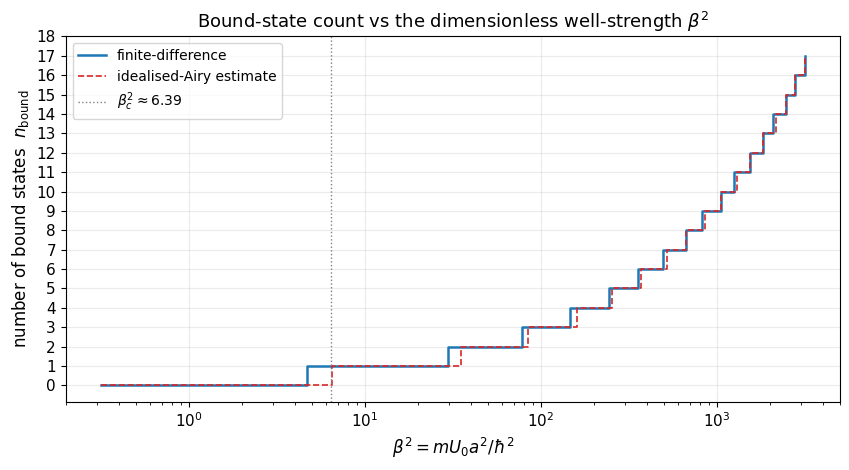

In [ ]:
# Sweep β² over several orders of magnitude
beta2_sweep = np.logspace(-0.5, 3.5, 220)            # 0.32 ... 3160
n_b = np.zeros_like(beta2_sweep, dtype=int)
for i, b2 in enumerate(beta2_sweep):
    E_, _, _, _ = solve_triangular_well(
        N=1500, L_tilde=4.0, beta2=b2, n_states=20,
    )
    n_b[i] = int(np.sum(E_ < 1.0))

# Airy-zero prediction: the largest n with |a_n|/(2β²)^{1/3} < 1
from scipy.special import ai_zeros
a_zeros20, _, _, _ = ai_zeros(40)
def airy_count(b2):
    thr = (2.0*b2)**(1.0/3.0)
    return int(np.sum(np.abs(a_zeros20) < thr))
n_airy = np.array([airy_count(b2) for b2 in beta2_sweep])

# Critical β² for the first level: |a_1|/(2β²)^{1/3} = 1
b2_crit = np.abs(a_zeros20[0])**3 / 2.0
print(f'Airy-prediction threshold for first bound state: β²_c ≈ {b2_crit:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.step(beta2_sweep, n_b, where='post', color='C0', lw=1.8,
        label='finite-difference')
ax.step(beta2_sweep, n_airy, where='post', color='C3', lw=1.2, ls='--',
        label=r'idealised-Airy estimate')
ax.axvline(b2_crit, color='gray', ls=':', lw=1.0,
           label=fr'$\beta^2_c \approx {b2_crit:.2f}$')
ax.set_xscale('log')
ax.set_xlabel(r'$\beta^2 = m U_0 a^2 / \hbar^2$')
ax.set_ylabel(r'number of bound states  $n_\mathrm{bound}$')
ax.set_title(r'Bound-state count vs the dimensionless well-strength $\beta^2$')
ax.legend(loc='upper left')
ax.set_yticks(range(0, max(n_b.max(), n_airy.max()) + 2))
plt.tight_layout()
plt.show()


**Discussion.** Two curves agree to a small handful of steps across four
decades of $\beta^{2}$.

* The finite-difference count tracks the idealised-Airy prediction almost
  everywhere. The only systematic offset comes from the *finite barrier
  correction* discussed in §3.5: a level the idealised theory considers
  "just bound" ($\tilde E_{n}^{\mathrm{Airy}\,\infty}$ just below 1) often
  actually escapes when the barrier saturates. So the true count is
  occasionally one less than the idealised estimate, by exactly one level
  near each transition.
* The critical $\beta^{2}_{c}=|a_{1}|^{3}/2\approx 6.39$ is the rigorous
  threshold from the idealised theory below which no bound state exists.
  The finite-barrier value differs by an order-one finite correction that
  one can read off the plot.
* On the *deep* end, $\beta^{2}\gg 1$, the count grows like
  $n_{\mathrm{bound}}\sim(2\beta^{2})^{1/3}/|a_{1}|$ — sublinear in $\beta$.
  Deeper / wider wells *do* hold more states, but slowly: a hundred-fold
  increase in $\beta^{2}$ gives only about a fivefold increase in
  $n_{\mathrm{bound}}$. This is a generic feature of one-sided linear
  confinement, distinct from the much faster $n\propto\sqrt{\beta}$ growth
  of the harmonic oscillator or $n\propto\beta$ for a deep square well.


## 4.6 Numerical accuracy and limitations

This section summarizes when the solver can be trusted and what its main
limitations are.

### What is well controlled

* **Accuracy.** The finite-difference method has $O(h^2)$ accuracy, which is
  confirmed by the convergence study in §4.3.

* **Eigenvalues and eigenvectors.** The Hamiltonian is real and symmetric, so
  the calculated eigenvalues are real and the eigenvectors are orthogonal.

* **Normalisation.** The wavefunctions are correctly normalised, with the
  probability conserved to machine precision.

* **Box size.** Bound-state energies are stable when the computational box
  is made larger, as shown in §4.4.

* **Cross-checks.** The finite-difference results agree well with the Airy
  solution and with the idealised Airy model where expected.

### Where one should be careful

* **Above-barrier states.** States with $\tilde E_n>1$ are box modes, so their
  energies depend on the chosen $\tilde L$. They should not be interpreted as
  physical bound states.

* **Near-threshold states.** States with $\tilde E_n\approx1$ are more sensitive
  to the box size because their wavefunctions decay slowly. These states
  require extra care when interpreting the results.

* **Extreme parameters.** Very large $\beta^2$ produces more closely spaced
  energy levels, so a finer grid may be needed to resolve them accurately.

* **Effective mass.** The model uses a constant effective mass $m^*$. A more
  realistic heterostructure would require a position-dependent effective mass
  $m^*(x)$.
  
### Performance

The solver is fast enough for interactive use. Changing the parameters in the
widget automatically recalculates the spectrum and updates the plots, making
it useful for exploring how the bound states change with the system parameters.